In [ ]:
import os 
import glob
import random
from pathlib import Path
from tqdm import tqdm


import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from insightface.app import FaceAnalysis

ROOT_DIR = Path("../").resolve()
DATA_DIR = ROOT_DIR / "data" / "face_verify"


# 1. Initialize Face Analyzer (uses GPU if available)
app = FaceAnalysis(name='buffalo_l', providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])
app.prepare(ctx_id=0, det_size=(640, 640))

In [7]:
anime_imgs = glob.glob(str(DATA_DIR / "anime" / "*.*g"))
real_imgs = glob.glob(str(DATA_DIR / "real" / "*.*g"))
art_imgs = glob.glob(str(DATA_DIR / "art" / "*.*g"))
statue_imgs = glob.glob(str(DATA_DIR / "statue" / "*.*g"))


print(f"Total anime images: {len(anime_imgs)}")
print(f"Total real images: {len(real_imgs)}")
print(f"Total art images: {len(art_imgs)}")
print(f"Total statue images: {len(statue_imgs)}")

Total anime images: 63565
Total real images: 25357
Total art images: 160
Total statue images: 68


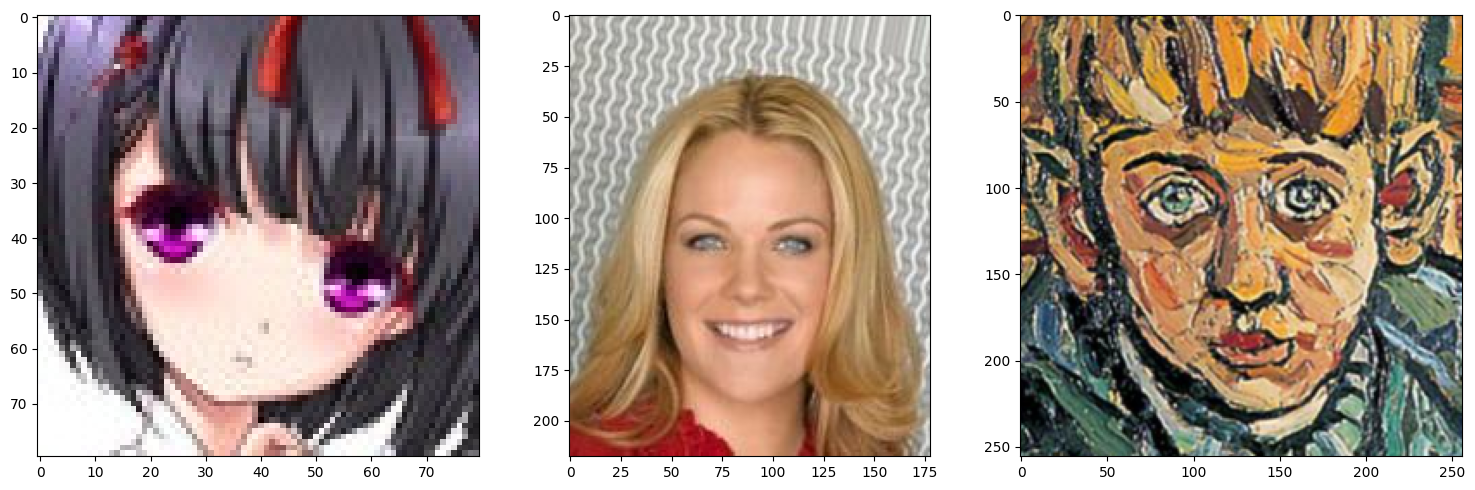

In [3]:
sample_anime = random.choice(anime_imgs)
sample_real = random.choice(real_imgs)
sample_art = random.choice(art_imgs)

# Create a row of 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
# Display each image in its respective subplot
for i, img_path in enumerate([sample_anime, sample_real, sample_art]):
    axes[i].imshow(Image.open(img_path))
    # axes[i].axis('off')  # Hide axes for a cleaner look
plt.tight_layout()
plt.show()

In [18]:
statue_raw_imgs = glob.glob(str(DATA_DIR / "gaming" / "GameplayRaw"/ "**/*.*g"))
statue_raw_imgs

['/home/octoopt/workspace/projects/personal/data_enrichment/data/face_verify/gaming/GameplayRaw/Roblox/image_974.png',
 '/home/octoopt/workspace/projects/personal/data_enrichment/data/face_verify/gaming/GameplayRaw/Roblox/image_573.png',
 '/home/octoopt/workspace/projects/personal/data_enrichment/data/face_verify/gaming/GameplayRaw/Roblox/image_179.png',
 '/home/octoopt/workspace/projects/personal/data_enrichment/data/face_verify/gaming/GameplayRaw/Roblox/image_501.png',
 '/home/octoopt/workspace/projects/personal/data_enrichment/data/face_verify/gaming/GameplayRaw/Roblox/image_689.png',
 '/home/octoopt/workspace/projects/personal/data_enrichment/data/face_verify/gaming/GameplayRaw/Roblox/image_17.png',
 '/home/octoopt/workspace/projects/personal/data_enrichment/data/face_verify/gaming/GameplayRaw/Roblox/image_85.png',
 '/home/octoopt/workspace/projects/personal/data_enrichment/data/face_verify/gaming/GameplayRaw/Roblox/image_227.png',
 '/home/octoopt/workspace/projects/personal/data_e

In [19]:

# 2. Setup output directory
STATUE_OUT_DIR = DATA_DIR / "gaming" / "Gameplay"
STATUE_OUT_DIR.mkdir(parents=True, exist_ok=True)

# 3. Process images
print(f"Processing {len(statue_raw_imgs)} images...")

for img_path in tqdm(statue_raw_imgs):
    img = cv2.imread(img_path)
    if img is None:
        continue
        
    # Detect faces
    faces = app.get(img)
    
    img_p = Path(img_path)
    stem = img_p.stem
    suffix = img_p.suffix
    
    if faces:
        # Process every face found in the image
        for i, face in enumerate(faces):
            bbox = face.bbox.astype(int)
            
            # Crop with boundary checks
            y1, x1, y2, x2 = max(0, bbox[1]), max(0, bbox[0]), min(img.shape[0], bbox[3]), min(img.shape[1], bbox[2])
            face_crop = img[y1:y2, x1:x2]
            
            # Generate name: originalname_00000.ext, originalname_00001.ext, etc.
            save_name = f"{stem}_{i:05d}{suffix}"
            save_path = str(STATUE_OUT_DIR / save_name)
            
            if face_crop.size > 0:
                cv2.imwrite(save_path, face_crop)
            else:
                cv2.imwrite(save_path, img)
    # else:
    #     # No face detected: keep the original image (save with original name)
    #     save_path = str(STATUE_OUT_DIR / f"{stem}{suffix}")
    #     cv2.imwrite(save_path, img)

print(f"Done! Results saved to: {STATUE_OUT_DIR}")

Processing 10000 images...


100%|██████████| 10000/10000 [07:11<00:00, 23.18it/s]

Done! Results saved to: /home/octoopt/workspace/projects/personal/data_enrichment/data/face_verify/gaming/Gameplay


Name:        open-images-v7-validation-100
Media type:  image
Num samples: 100
Persistent:  False
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    detections:       fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    points:           fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Keypoints)
    segmentations:    fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)

In [5]:
def rename_images(directory_path, prefix="img"):
    """
    Renames all images in a directory to img_00001.ext, img_00002.ext, etc.
    """
    # Convert string path to Path object
    dir_path = Path(directory_path)
    
    # Define valid image extensions
    valid_extensions = ('.jpg', '.jpeg', '.png', '.webp', '.bmp')
    
    # Get all image files and sort them to maintain consistency
    image_files = sorted([
        f for f in dir_path.iterdir() 
        if f.suffix.lower() in valid_extensions
    ])
    
    print(f"Found {len(image_files)} images to rename.")
    
    for i, file_path in enumerate(image_files, start=1):
        # Create the new name: img_00001.jpg
        new_name = f"{prefix}_{i:05d}{file_path.suffix.lower()}"
        new_path = dir_path / new_name
        
        # Rename the file
        file_path.rename(new_path)
        
    print("Renaming complete.")

# Usage:
# rename_images(DATA_DIR / "statue")